In [57]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

In [58]:
df = pd.read_csv('Universities.csv')

<IPython.core.display.Javascript object>

In [59]:
df

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,Brown,1310,89,22,13,22704,94
1,CalTech,1415,100,25,6,63575,81
2,CMU,1260,62,59,9,25026,72
3,Columbia,1310,76,24,12,31510,88
4,Cornell,1280,83,33,13,21864,90
5,Dartmouth,1340,89,23,10,32162,95
6,Duke,1315,90,30,12,31585,95
7,Georgetown,1255,74,24,12,20126,92
8,Harvard,1400,91,14,11,39525,97
9,JohnsHopkins,1305,75,44,7,58691,87


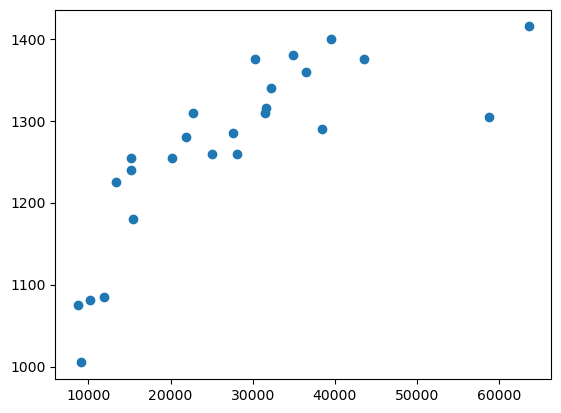

In [60]:
plt.scatter(df['Expenses'], df['SAT'])

In [61]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df[['Expenses', 'SAT']])
df_scaled = scaler.transform(df[['Expenses', 'SAT']])

In [62]:
df.drop(columns=['Expenses', 'SAT'], inplace=True)
df = pd.concat([df, pd.DataFrame(df_scaled, columns=['Expenses', 'SAT'])], axis=1)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(df[['Expenses', 'SAT']])



c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=0)

In [ ]:

df['Cluster'] = kmeans.labels_
df['Cluster'] = df['Cluster'].astype(str)
df['Cluster'] = 'Cluster ' + df['Cluster']
df['Cluster']


0     Cluster 2
1     Cluster 1
2     Cluster 2
3     Cluster 1
4     Cluster 2
5     Cluster 1
6     Cluster 1
7     Cluster 2
8     Cluster 1
9     Cluster 1
10    Cluster 1
11    Cluster 2
12    Cluster 2
13    Cluster 0
14    Cluster 1
15    Cluster 0
16    Cluster 1
17    Cluster 0
18    Cluster 2
19    Cluster 1
20    Cluster 2
21    Cluster 2
22    Cluster 2
23    Cluster 0
24    Cluster 1
Name: Cluster, dtype: object

<Axes: xlabel='Cluster'>

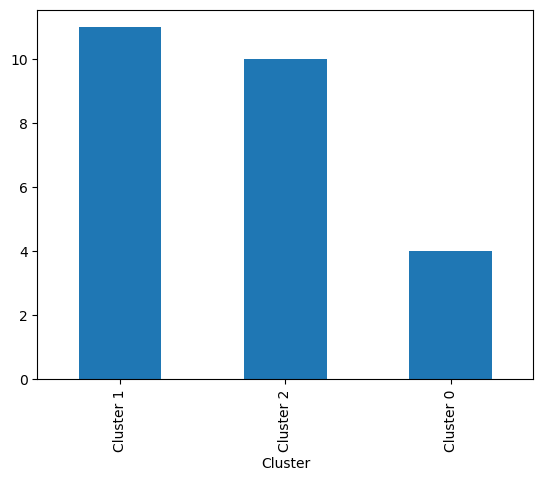

In [67]:

df['Cluster'].value_counts()
df['Cluster'].value_counts().plot(kind='bar')

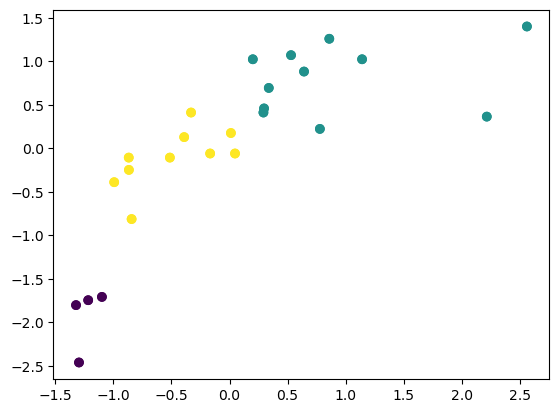

In [68]:
plt.scatter(df['Expenses'], df['SAT'], c=df['Cluster'].astype('category').cat.codes, cmap='viridis')
plt.scatter(df['Expenses'], df['SAT'], c=kmeans.labels_, cmap='viridis')


In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(df[['Expenses', 'SAT']], kmeans.labels_)

0.4984200183251404

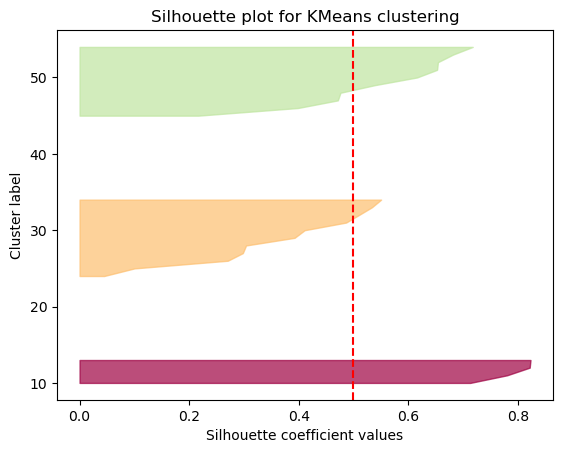

In [71]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
cluster_labels = np.unique(kmeans.labels_)
n_clusters = cluster_labels.shape[0]
sample_silhouette_values = silhouette_samples(df[['Expenses', 'SAT']], kmeans.labels_)
y_lower = 10
for i, c in enumerate(cluster_labels):
    c_silhouette_values = sample_silhouette_values[kmeans.labels_ == c]
    c_silhouette_values.sort()
    y_upper = y_lower + len(c_silhouette_values)
    color = cm.Spectral(float(i) / n_clusters)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)
    y_lower = y_upper + 10
plt.title('Silhouette plot for KMeans clustering')
plt.xlabel('Silhouette coefficient values')
plt.ylabel('Cluster label')
plt.axvline(x=silhouette_score(df[['Expenses', 'SAT']], kmeans.labels_), color='red', linestyle='--')
plt.show()